/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_1984/2071324040.py:3: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



DEUTSCH ALGORITHM - CONSTANT FUNCTION

Oracle Circuit:
     
q_0: 
     
q_1: 
     

Complete Deutsch Circuit:
     ┌───┐┌───┐
q_0: ┤ H ├┤ H ├
     ├───┤├───┤
q_1: ┤ X ├┤ H ├
     └───┘└───┘

MEASUREMENT RESULTS
Shots : 1000
0 count : 1000
1 count : 0
P(0) : 1.0000
P(1) : 0.0000

RESULT: 0
The function is CONSTANT.


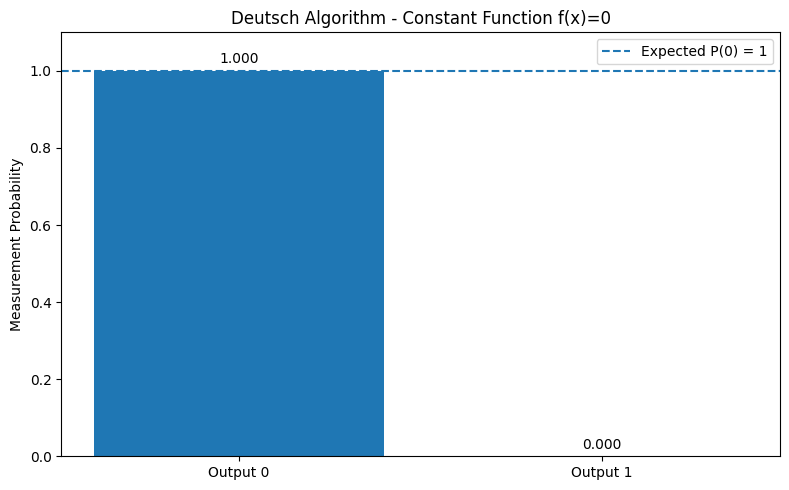

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

SHOTS = 1000

# ---------------------------------------------------------
# CONSTANT ORACLE: f(x) = 0
# ---------------------------------------------------------

def constant_oracle():
    oracle = QuantumCircuit(2)

    # f(x) = 0
    # No X gate is required because output remains unchanged.

    return oracle


# ---------------------------------------------------------
# DEUTSCH ALGORITHM
# ---------------------------------------------------------

qc = QuantumCircuit(2)

# Initial state |0>|1>
qc.x(1)

# Put both qubits into superposition
qc.h(0)
qc.h(1)

# Apply constant oracle
oracle = constant_oracle()
qc.compose(oracle, inplace=True)

# Interference on control qubit
qc.h(0)

print("\nDEUTSCH ALGORITHM - CONSTANT FUNCTION")
print("=" * 60)

print("\nOracle Circuit:")
print(oracle.draw())

print("\nComplete Deutsch Circuit:")
print(qc.draw())

# ---------------------------------------------------------
# STATEVECTOR SIMULATION
# ---------------------------------------------------------

state = Statevector.from_instruction(qc)

probabilities = state.probabilities()

# Control qubit is q0.
# Probability of q0 = 0 and q0 = 1
p0 = 0.0
p1 = 0.0

for index, probability in enumerate(probabilities):
    bit = format(index, "02b")
    q0 = bit[-1]

    if q0 == "0":
        p0 += probability
    else:
        p1 += probability

# ---------------------------------------------------------
# MEASUREMENT COUNTS
# ---------------------------------------------------------

rng = np.random.default_rng(42)

samples = rng.choice(
    [0, 1],
    size=SHOTS,
    p=[p0, p1]
)

count_0 = int(np.sum(samples == 0))
count_1 = int(np.sum(samples == 1))

print("\nMEASUREMENT RESULTS")
print("=" * 60)

print(f"Shots : {SHOTS}")
print(f"0 count : {count_0}")
print(f"1 count : {count_1}")
print(f"P(0) : {count_0 / SHOTS:.4f}")
print(f"P(1) : {count_1 / SHOTS:.4f}")

if count_0 > count_1:
    print("\nRESULT: 0")
    print("The function is CONSTANT.")
else:
    print("\nRESULT: 1")
    print("The function is BALANCED.")

# ---------------------------------------------------------
# GRAPH
# ---------------------------------------------------------

labels = ["Output 0", "Output 1"]
values = [count_0 / SHOTS, count_1 / SHOTS]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)

plt.axhline(
    1.0,
    linestyle="--",
    label="Expected P(0) = 1"
)

plt.ylabel("Measurement Probability")
plt.title("Deutsch Algorithm - Constant Function f(x)=0")
plt.ylim(0, 1.1)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.legend()
plt.tight_layout()
plt.show()